In [11]:
!pip install -q lightning torchmetrics torchvision


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from torchmetrics import Accuracy
import matplotlib.pyplot as plt


In [13]:
# Imagenette data (Part 1, no augmentation)
IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

train_data = datasets.Imagenette(
    root="imagenette_data",
    split="train",
    download=True,
    transform=transform
)

val_data = datasets.Imagenette(
    root="imagenette_data",
    split="val",
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False, num_workers=2)

print("Num classes:", len(train_data.classes))
print("Classes:", train_data.classes)


Num classes: 10
Classes: [('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]


In [14]:
class BasicCNN(L.LightningModule):
    def __init__(self, num_classes=10, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 128 -> 64
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 64 -> 32
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2) # 32 -> 16
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

        # Separate metrics for train and val
        self.train_acc_metric = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc_metric   = Accuracy(task="multiclass", num_classes=num_classes)

        # Epoch-level metrics for plotting
        self.train_losses = []
        self.val_losses   = []
        self.train_accuracies = []
        self.val_accuracies   = []

        # Buffers for step outputs each epoch
        self.training_step_outputs   = []
        self.validation_step_outputs = []

    def forward(self, x):
        feats = self.feature_extractor(x)
        logits = self.classifier(feats)
        return logits

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    # ---------- TRAIN ----------
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        acc = self.train_acc_metric(logits.softmax(1), y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc,   prog_bar=True, on_step=False, on_epoch=True)

        self.training_step_outputs.append({"loss": loss, "acc": acc})
        return loss

    def on_train_epoch_end(self):
        avg_loss = torch.stack([x["loss"] for x in self.training_step_outputs]).mean()
        avg_acc  = torch.stack([x["acc"]  for x in self.training_step_outputs]).mean()

        self.train_losses.append(avg_loss.item())
        self.train_accuracies.append(avg_acc.item())

        self.training_step_outputs.clear()
        self.train_acc_metric.reset()

    # ---------- VALIDATION ----------
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        acc = self.val_acc_metric(logits.softmax(1), y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)

        self.validation_step_outputs.append({"val_loss": loss, "val_acc": acc})
        return {"val_loss": loss, "val_acc": acc}

    def on_validation_epoch_end(self):
        avg_loss = torch.stack([x["val_loss"] for x in self.validation_step_outputs]).mean()
        avg_acc  = torch.stack([x["val_acc"]  for x in self.validation_step_outputs]).mean()

        self.val_losses.append(avg_loss.item())
        self.val_accuracies.append(avg_acc.item())

        self.log("hp_metric", avg_acc)  # optional HP metric
        self.validation_step_outputs.clear()
        self.val_acc_metric.reset()


In [15]:
num_classes = len(train_data.classes)
model_basic = BasicCNN(num_classes=num_classes, lr=1e-3)

trainer = L.Trainer(
    max_epochs=20,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3),
        ModelCheckpoint(
            dirpath="checkpoints_part1",
            filename="basic_cnn_imagenette_part1",
            save_last=True,
            save_top_k=1,
            monitor="val_loss",
            mode="min",
        ),
    ]
)

trainer.fit(model_basic, train_loader, val_loader)

# -------- TEST EVALUATION (using val_loader as test here) --------
model_basic.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model_basic.to(device)

test_losses = []
test_acc_metric = Accuracy(task="multiclass", num_classes=num_classes).to(device)

with torch.no_grad():
    for x, y in val_loader:  # if you have test_loader, use that instead
        x, y = x.to(device), y.to(device)
        logits = model_basic(x)
        loss = F.cross_entropy(logits, y)
        test_losses.append(loss.item())
        test_acc_metric.update(torch.softmax(logits, dim=1), y)

test_loss = sum(test_losses) / len(test_losses)
test_acc  = float(test_acc_metric.compute())

print(f"Final Test Loss (Part 1): {test_loss:.4f}")
print(f"Final Test Accuracy (Part 1): {test_acc:.4f}")


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name              | Type               | Params | Mode 
-----------------------------------------------------------------
0 | feature_extractor | Sequential         | 93.2 K | train
1 | classifier        | Sequential         | 8.4 M  | train
2 | train_acc_metric  | MulticlassAccuracy | 0      | train
3 | val_acc_metric    | MulticlassAccuracy | 0      | train
-----------------------------------------------------------------
8.5 M     Trainable params
0         Non-trainable params
8.5 M     Total params
33.939    Total estimated model params size (MB)
17        Modules in train mode
0         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Final Test Loss (Part 1): 1.5629
Final Test Accuracy (Part 1): 0.6619


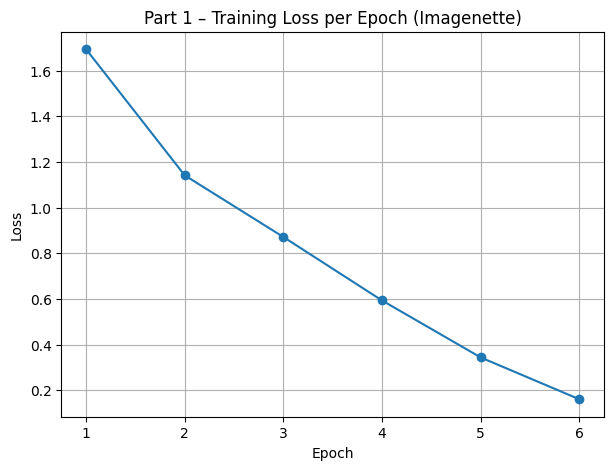

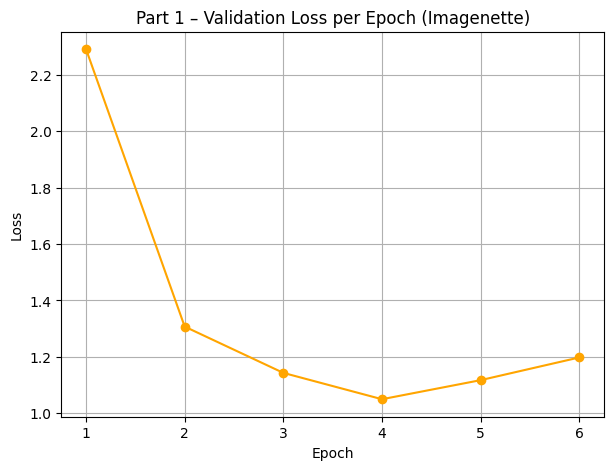

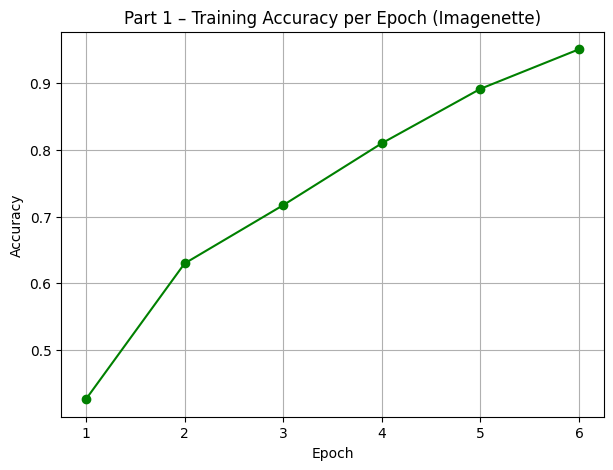

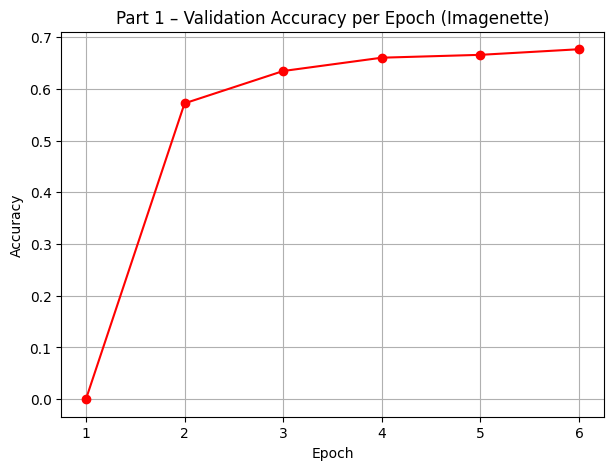

In [18]:
# Access stored metrics
train_loss = model_basic.train_losses
val_loss   = model_basic.val_losses
train_acc  = model_basic.train_accuracies
val_acc    = model_basic.val_accuracies

num_epochs = min(len(train_loss), len(val_loss))
epochs = range(1, num_epochs + 1)

train_loss_sliced = train_loss[:num_epochs]
val_loss_sliced   = val_loss[:num_epochs]
train_acc_sliced  = train_acc[:num_epochs]
val_acc_sliced    = val_acc[:num_epochs]

# Training Loss
plt.figure(figsize=(7, 5))
plt.plot(epochs, train_loss_sliced, marker='o')
plt.title("Part 1 – Training Loss per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Validation Loss
plt.figure(figsize=(7, 5))
plt.plot(epochs, val_loss_sliced, marker='o', color='orange')
plt.title("Part 1 – Validation Loss per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Training Accuracy
plt.figure(figsize=(7, 5))
plt.plot(epochs, train_acc_sliced, marker='o', color='green')
plt.title("Part 1 – Training Accuracy per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Validation Accuracy
plt.figure(figsize=(7, 5))
plt.plot(epochs, val_acc_sliced, marker='o', color='red')
plt.title("Part 1 – Validation Accuracy per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [16]:
# ===== IMPORTS (safe even if already imported) =====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torchmetrics import Accuracy
import matplotlib.pyplot as plt

# ===== 1) DATASET WITH AUGMENTATION (Part 2) =====

IMG_SIZE = 128

train_transform_reg = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

val_transform_reg = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

train_data_reg = datasets.Imagenette(
    root="imagenette_data",
    split="train",
    download=True,
    transform=train_transform_reg
)

val_data_reg = datasets.Imagenette(
    root="imagenette_data",
    split="val",
    download=True,
    transform=val_transform_reg
)

train_loader_reg = DataLoader(train_data_reg, batch_size=64, shuffle=True, num_workers=2)
val_loader_reg   = DataLoader(val_data_reg,   batch_size=64, shuffle=False, num_workers=2)

print("Num classes (reg):", len(train_data_reg.classes))
print("Classes:", train_data_reg.classes)




Num classes (reg): 10
Classes: [('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]


In [19]:
# ===== 2) REGULARIZED CNN MODEL (same convs + dropout) =====

class RegularizedCNN(L.LightningModule):
    def __init__(self, num_classes=10, dropout_p=0.3, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        # Feature extractor: SAME as Part 1
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 128 -> 64
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 64 -> 32
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2) # 32 -> 16
        )

        # After 3 pools: feature map is 128 x 16 x 16  (NOT 28x28)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)
        )

        # Separate accuracy metrics for train/val
        self.train_acc_metric = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc_metric   = Accuracy(task="multiclass", num_classes=num_classes)

        # Epoch-level metrics (for plotting)
        self.train_losses = []
        self.val_losses   = []
        self.train_accuracies = []
        self.val_accuracies   = []

        # Step buffers
        self.training_step_outputs   = []
        self.validation_step_outputs = []

    def forward(self, x):
        feats = self.feature_extractor(x)
        logits = self.classifier(feats)
        return logits

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    # ---------- TRAIN ----------
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = self.train_acc_metric(logits.softmax(1), y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)

        self.training_step_outputs.append({"loss": loss, "acc": acc})
        return loss

    def on_train_epoch_end(self):
        avg_loss = torch.stack([x["loss"] for x in self.training_step_outputs]).mean()
        avg_acc  = torch.stack([x["acc"]  for x in self.training_step_outputs]).mean()

        self.train_losses.append(avg_loss.item())
        self.train_accuracies.append(avg_acc.item())

        self.training_step_outputs.clear()
        self.train_acc_metric.reset()

    # ---------- VALIDATION ----------
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = self.val_acc_metric(logits.softmax(1), y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)

        self.validation_step_outputs.append({"val_loss": loss, "val_acc": acc})
        return {"val_loss": loss, "val_acc": acc}

    def on_validation_epoch_end(self):
        avg_loss = torch.stack([x["val_loss"] for x in self.validation_step_outputs]).mean()
        avg_acc  = torch.stack([x["val_acc"]  for x in self.validation_step_outputs]).mean()

        self.val_losses.append(avg_loss.item())
        self.val_accuracies.append(avg_acc.item())

        self.log("hp_metric", avg_acc)
        self.validation_step_outputs.clear()
        self.val_acc_metric.reset()



In [20]:
# ===== 3) TRAIN REGULARIZED MODEL (Part 2) =====

num_classes_reg = len(train_data_reg.classes)
model_reg = RegularizedCNN(num_classes=num_classes_reg, dropout_p=0.3, lr=1e-3)

trainer = L.Trainer(
    max_epochs=10,
    accelerator="auto",
    devices="auto",
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3),
        ModelCheckpoint(
            dirpath="checkpoints_part2",
            filename="regularized_imagenette_part2",
            save_top_k=1,
            monitor="val_acc",
            mode="max",
        )
    ],
    log_every_n_steps=20,
)

trainer.fit(model_reg, train_loader_reg, val_loader_reg)


# ===== 4) TEST EVALUATION (using val_loader_reg as test here) =====

model_reg.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model_reg.to(device)

acc_metric = Accuracy(task="multiclass", num_classes=num_classes_reg).to(device)
test_losses = []

with torch.no_grad():
    for x, y in val_loader_reg:   # if you had separate test_loader_reg, use it here
        x, y = x.to(device), y.to(device)
        logits = model_reg(x)
        loss = F.cross_entropy(logits, y)
        test_losses.append(loss.item())
        acc_metric.update(torch.softmax(logits, dim=1), y)

test_loss = sum(test_losses) / len(test_losses)
test_acc  = float(acc_metric.compute())

print("\nREGULARIZED MODEL TEST RESULTS (Part 2)")
print(f" Test Loss:     {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")
print("==============================================")




INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name              | Type               | Params | Mode 
-----------------------------------------------------------------
0 | feature_extractor | Sequential         | 93.2 K | train
1 | classifier        | Sequential         | 8.4 M  | train
2 | train_acc_metric  | MulticlassAccuracy | 0      | train
3 | val_acc_metric    | MulticlassAccuracy | 0      | train
-----------------------------------------------------------------
8.5 M     Trainable params
0         Non-trainable params
8.5 M     Total params
33.939    Total estimated model params size (MB)
19        Modules in train mode
0         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.



REGULARIZED MODEL TEST RESULTS (Part 2)
 Test Loss:     0.8737
 Test Accuracy: 0.7297


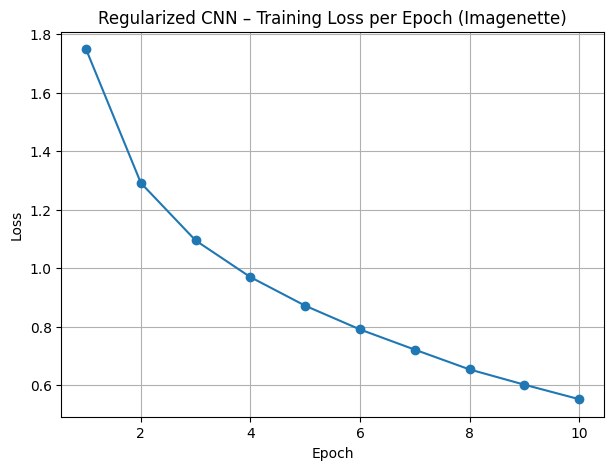

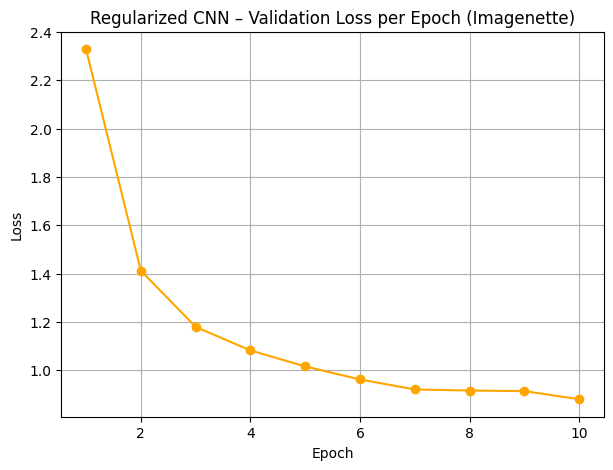

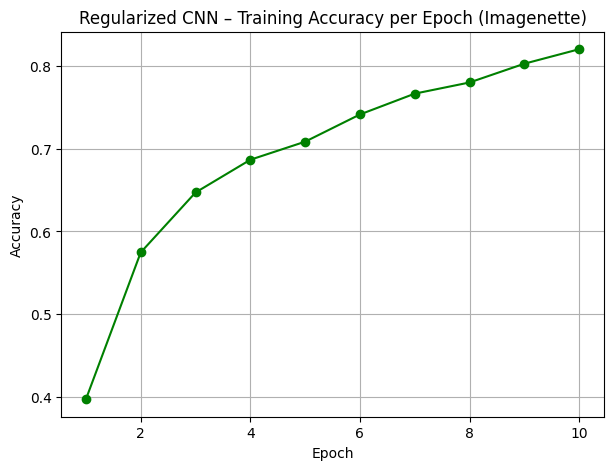

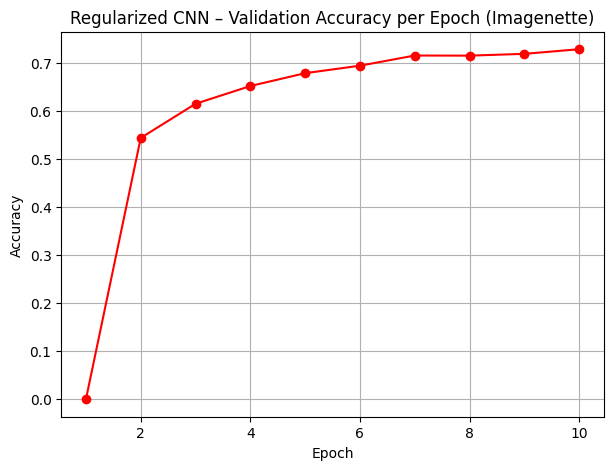

In [21]:
# ===== 5) PLOTS FOR PART 2 =====

train_loss = model_reg.train_losses
val_loss   = model_reg.val_losses
train_acc  = model_reg.train_accuracies
val_acc    = model_reg.val_accuracies

num_epochs = min(len(train_loss), len(val_loss))
epochs = range(1, num_epochs + 1)

train_loss_sliced = train_loss[:num_epochs]
val_loss_sliced   = val_loss[:num_epochs]
train_acc_sliced  = train_acc[:num_epochs]
val_acc_sliced    = val_acc[:num_epochs]

# Training Loss
plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss_sliced, marker='o')
plt.title("Regularized CNN – Training Loss per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Validation Loss
plt.figure(figsize=(7,5))
plt.plot(epochs, val_loss_sliced, marker='o', color='orange')
plt.title("Regularized CNN – Validation Loss per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Training Accuracy
plt.figure(figsize=(7,5))
plt.plot(epochs, train_acc_sliced, marker='o', color='green')
plt.title("Regularized CNN – Training Accuracy per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Validation Accuracy
plt.figure(figsize=(7,5))
plt.plot(epochs, val_acc_sliced, marker='o', color='red')
plt.title("Regularized CNN – Validation Accuracy per Epoch (Imagenette)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [23]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchmetrics import Accuracy
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import glob

# ----- CIFAR-10 DATASET -----

IMG_SIZE = 128  # to match BasicCNN's 3 maxpools -> 16x16

cifar_train_t = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

cifar_val_t = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_cifar = datasets.CIFAR10(root="cifar_data", train=True,  download=True, transform=cifar_train_t)
test_cifar  = datasets.CIFAR10(root="cifar_data", train=False, download=True, transform=cifar_val_t)

train_loader_cifar = DataLoader(train_cifar, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_cifar   = DataLoader(test_cifar,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("CIFAR10 classes:", train_cifar.classes)


CIFAR10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [24]:
# ===== CIFAR-10 FROM SCRATCH =====

num_classes_cifar = 10  # CIFAR-10

# BasicCNN must already be defined from Part 1
model_cifar_scratch = BasicCNN(num_classes=num_classes_cifar, lr=1e-3)

trainer_cifar_scratch = L.Trainer(
    max_epochs=15,
    accelerator="auto",
    devices="auto",
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3),
        ModelCheckpoint(
            dirpath="checkpoints_cifar_scratch",
            filename="cifar_scratch",
            save_top_k=1,
            monitor="val_acc",
            mode="max",
        ),
    ],
    log_every_n_steps=20,
)

trainer_cifar_scratch.fit(model_cifar_scratch, train_loader_cifar, val_loader_cifar)

# ---- Test on CIFAR-10 test set ----
model_cifar_scratch.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model_cifar_scratch.to(device)

acc_metric_scratch = Accuracy(task="multiclass", num_classes=num_classes_cifar).to(device)
test_losses_scratch = []

with torch.no_grad():
    for x, y in val_loader_cifar:
        x, y = x.to(device), y.to(device)
        logits = model_cifar_scratch(x)
        loss = F.cross_entropy(logits, y)
        test_losses_scratch.append(loss.item())
        acc_metric_scratch.update(torch.softmax(logits, dim=1), y)

test_loss_scratch = sum(test_losses_scratch) / len(test_losses_scratch)
test_acc_scratch  = float(acc_metric_scratch.compute())

print("\nCIFAR-10 FROM SCRATCH")
print(f" Test Loss:     {test_loss_scratch:.4f}")
print(f" Test Accuracy: {test_acc_scratch:.4f}")
print("==============================================")


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name              | Type               | Params | Mode 
-----------------------------------------------------------------
0 | feature_extractor | Sequential         | 93.2 K | train
1 | classifier        | Sequential         | 8.4 M  | train
2 | train_acc_metric  | MulticlassAccuracy | 0      | train
3 | val_acc_metric    | MulticlassAccuracy | 0      | train
-----------------------------------------------------------------
8.5 M     Trainable params
0         Non-trainable params
8.5 M     Total params
33.939    Total estimated model params size (MB)
17        Modules in train mode
0         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


CIFAR-10 FROM SCRATCH
 Test Loss:     0.7530
 Test Accuracy: 0.7526


In [26]:
# ===== TRANSFER LEARNING: Load Imagenette-pretrained RegularizedCNN =====

# We already found this above:
# imagenette_ckpt_path = "checkpoints_part2/regularized_imagenette_part2.ckpt"

print("Using Imagenette checkpoint:", imagenette_ckpt_path)

# Load model with pretrained weights from Part 2 (RegularizedCNN)
model_cifar_tl = RegularizedCNN.load_from_checkpoint(imagenette_ckpt_path)

# Use a smaller LR for fine-tuning
model_cifar_tl.lr = 5e-4

trainer_cifar_tl = L.Trainer(
    max_epochs=15,
    accelerator="auto",
    devices="auto",
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3),
        ModelCheckpoint(
            dirpath="checkpoints_cifar_tl",
            filename="cifar_tl",
            save_top_k=1,
            monitor="val_acc",
            mode="max",
        ),
    ],
    log_every_n_steps=20,
)

trainer_cifar_tl.fit(model_cifar_tl, train_loader_cifar, val_loader_cifar)

# ---- Test TL model on CIFAR-10 test set ----
model_cifar_tl.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model_cifar_tl.to(device)

acc_metric_tl = Accuracy(task="multiclass", num_classes=10).to(device)
test_losses_tl = []

with torch.no_grad():
    for x, y in val_loader_cifar:
        x, y = x.to(device), y.to(device)
        logits = model_cifar_tl(x)
        loss = F.cross_entropy(logits, y)
        test_losses_tl.append(loss.item())
        acc_metric_tl.update(torch.softmax(logits, dim=1), y)

test_loss_tl = sum(test_losses_tl) / len(test_losses_tl)
test_acc_tl  = float(acc_metric_tl.compute())

print("\nCIFAR-10 TRANSFER LEARNING (Imagenette → CIFAR-10)")
print(f" Test Loss:     {test_loss_tl:.4f}")
print(f" Test Accuracy: {test_acc_tl:.4f}")
print("==============================================")


Using Imagenette checkpoint: checkpoints_part2/regularized_imagenette_part2.ckpt


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name              | Type               | Params | Mode 
-----------------------------------------------------------------
0 | feature_extractor | Sequential         | 93.2 K | train
1 | classifier        | Sequential         | 8.4 M  | train
2 | train_acc_metric  | MulticlassAccuracy | 0      | train
3 | val_acc_metric    | MulticlassAccuracy | 0      | train
-----------------------------------------------------------------
8.5 M     Trainable params
0         Non-trainable params
8.5 M     Total params
33.939    Total estimated model params size (MB)
19        Modules in train mode
0         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.



CIFAR-10 TRANSFER LEARNING (Imagenette → CIFAR-10)
 Test Loss:     0.6720
 Test Accuracy: 0.7662


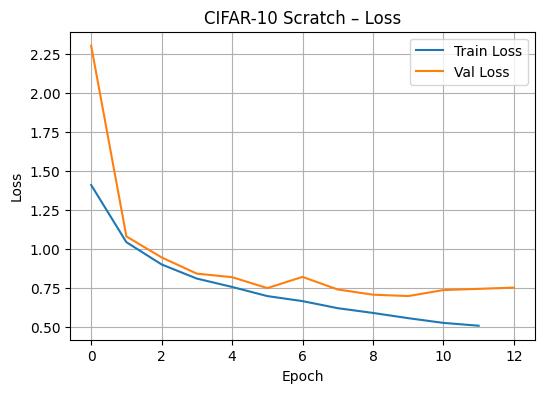

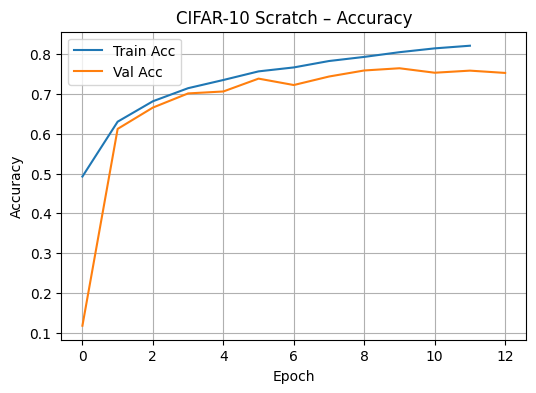

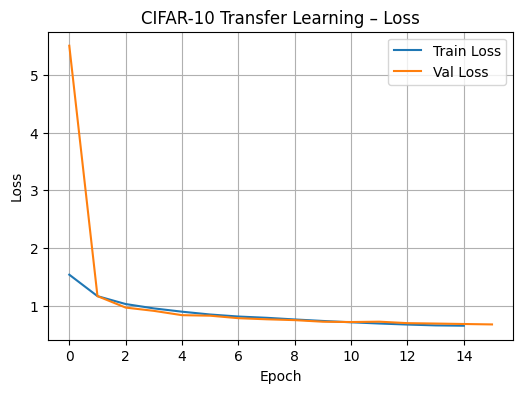

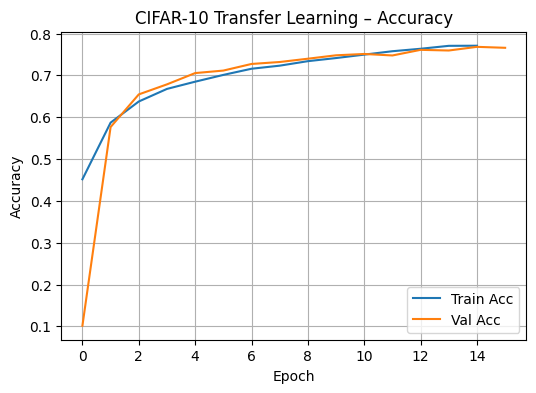

In [27]:
# ===== PLOTS: CIFAR-10 SCRATCH =====

plt.figure(figsize=(6,4))
plt.plot(model_cifar_scratch.train_losses, label="Train Loss")
plt.plot(model_cifar_scratch.val_losses,   label="Val Loss")
plt.title("CIFAR-10 Scratch – Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model_cifar_scratch.train_accuracies, label="Train Acc")
plt.plot(model_cifar_scratch.val_accuracies,   label="Val Acc")
plt.title("CIFAR-10 Scratch – Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ===== PLOTS: CIFAR-10 TRANSFER LEARNING =====

plt.figure(figsize=(6,4))
plt.plot(model_cifar_tl.train_losses, label="Train Loss")
plt.plot(model_cifar_tl.val_losses,   label="Val Loss")
plt.title("CIFAR-10 Transfer Learning – Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model_cifar_tl.train_accuracies, label="Train Acc")
plt.plot(model_cifar_tl.val_accuracies,   label="Val Acc")
plt.title("CIFAR-10 Transfer Learning – Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [28]:
import torch
import torch.nn.functional as F
from torchmetrics import Accuracy

# --- TEST LOADER (same val_loader_cifar you used earlier) ---
device = "cuda" if torch.cuda.is_available() else "cpu"

model_cifar_tl.eval()
model_cifar_tl.to(device)

acc_metric = Accuracy(task="multiclass", num_classes=10).to(device)
test_losses = []

with torch.no_grad():
    for x, y in val_loader_cifar:   # use test_loader_cifar if you created one
        x, y = x.to(device), y.to(device)
        logits = model_cifar_tl(x)
        loss = F.cross_entropy(logits, y)
        test_losses.append(loss.item())
        acc_metric.update(torch.softmax(logits, dim=1), y)

final_test_loss = sum(test_losses) / len(test_losses)
final_test_acc  = float(acc_metric.compute())

print("\n===== FINAL FINE-TUNED CIFAR-10 RESULTS =====")
print(f" Test Loss:     {final_test_loss:.4f}")
print(f" Test Accuracy: {final_test_acc:.4f}")
print("==============================================")



===== FINAL FINE-TUNED CIFAR-10 RESULTS =====
 Test Loss:     0.6720
 Test Accuracy: 0.7662
